# Plot Hovmöller Diagrams for SIC, SST, SSS

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:37961")
client

<Client: 'tcp://127.0.0.1:37961' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [159]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

In [44]:
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(70,390))

### Identify line to plot

In [83]:
bathy_beaufort = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.where(HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth>0)

In [111]:
depth_71N = bathy_beaufort.where((depth_beaufort.YC >= 71) & (depth_beaufort.YC < 71.05))

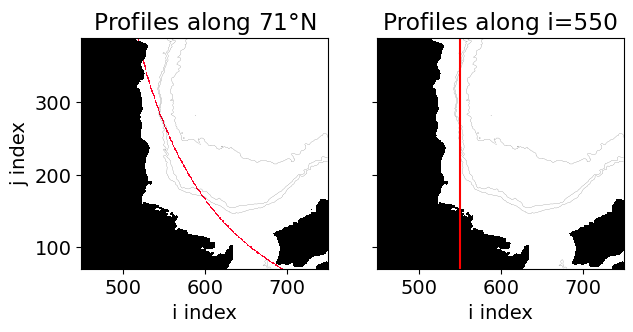

In [112]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=[7,3],sharey=True)
depth_71N_mask = xr.where(depth_71N.notnull(), 1, np.nan)
depth_71N_mask.plot(ax=ax1,vmin=0,vmax=0.8,cmap='gist_rainbow_r',add_colorbar=False);
HH_land_beaufort.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
bathy_beaufort.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])

HH_land_beaufort.plot(ax=ax2,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
bathy_beaufort.plot.contour(ax=ax2, colors='k', linewidths=0.1, levels=[500,1000,3000])
ax2.axvline(x=550,c='red')

ax1.set_xlabel('i index')
ax1.set_ylabel('j index')
ax2.set_ylabel('')
ax2.set_xlabel('i index')
ax1.set_title(f'Profiles along 71$\degree$N');
ax2.set_title(f'Profiles along i=550');

## Plot Hovmöller Diagrams

### SIC

In [160]:
ice_select = ice_da.isel(i=550,j=slice(150,390))

In [161]:
# convert time to Day of Year (DOY)
doy = ice_select['time'].dt.dayofyear

# group by DOY and compute the mean across years
ice_conc_doy_mean = ice_select.groupby(doy).mean(dim='time')

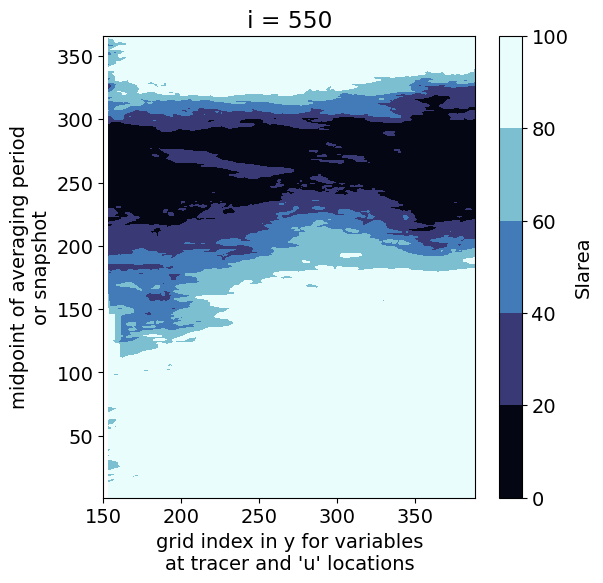

In [162]:
# Define contour levels
levels = np.arange(0, 110, 10)  # Ensure it fully covers the data range

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Plot Hovmöller Diagram using xarray's contourf function
cbar_plot = ice_conc_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap=cmocean.cm.ice, levels=levels
)

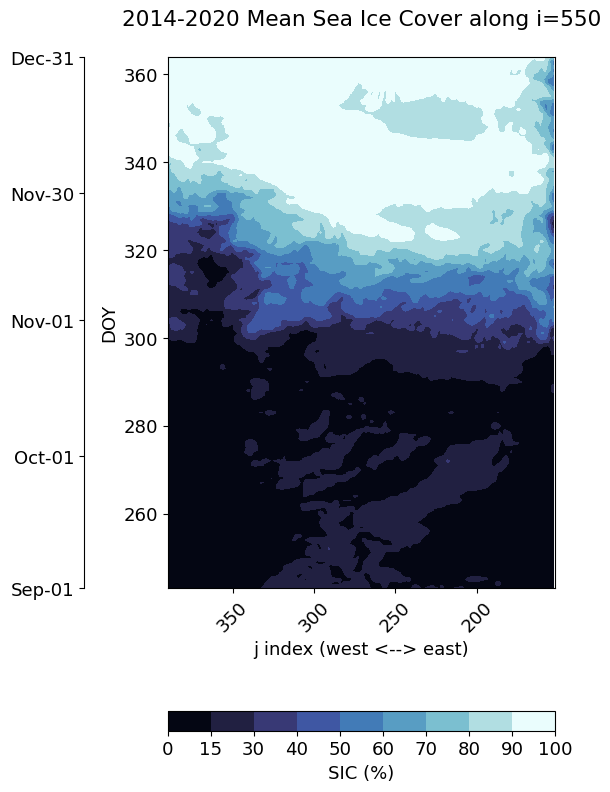

In [171]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 10))

# # Plot the Hovmöller diagram
# cbar_plot = ice_conc_doy_mean.plot(
#     x='j', y='dayofyear', cmap=cmocean.cm.ice, robust=True, ax=ax, add_colorbar=False)

# Plot Hovmöller Diagram using xarray's contourf function
levels=[0,15,30,40,50,60,70,80,90,100]
cbar_plot = ice_conc_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap=cmocean.cm.ice, levels=levels, add_colorbar=False)

# Plot contour for 80% cover
ice_conc_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap='r', levels=[80], add_colorbar=False)

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('2014-2020 Mean Sea Ice Cover along i=550\n')
ax.set_xlabel('j index (west <--> east)')
ax.set_ylabel('DOY')
ax.set_xlim(390, 152)
ax.set_ylim(243, 364)
ax.tick_params(axis='x', rotation=45)

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.16)
cbar.set_label("SIC (%)")

plt.show()

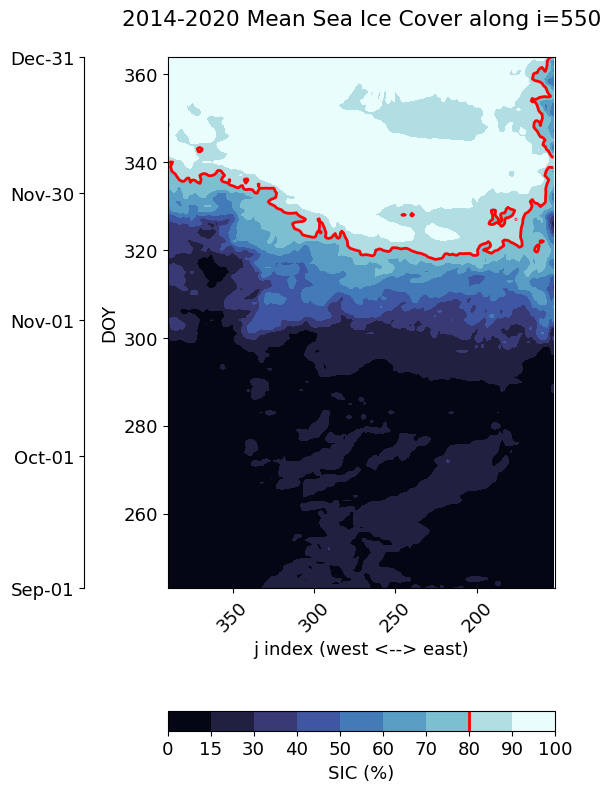

In [182]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import cmocean

plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 10))

# Define contour levels
levels = [0, 15, 30, 40, 50, 60, 70, 80, 90, 100]

# Plot Hovmöller Diagram
cbar_plot = ice_conc_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap=cmocean.cm.ice, levels=levels, add_colorbar=False
)

# Plot contour line for 80% sea ice concentration
contour_80 = ice_conc_doy_mean.plot.contour(
    ax=ax, x='j', y='dayofyear', levels=[80], colors='r', linewidths=2
)

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('2014-2020 Mean Sea Ice Cover along i=550\n')
ax.set_xlabel('j index (west <--> east)')
ax.set_ylabel('DOY')
ax.set_xlim(390, 152)
ax.set_ylim(243, 364)
ax.tick_params(axis='x', rotation=45)

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.16)
cbar.set_label("SIC (%)")

# Add a red marker at 80% on the colorbar
cbar.ax.axvline(x=80, color='r', linewidth=2)

plt.show()

### SST

In [172]:
sst_select = theta_da.isel(i=550,j=slice(150,390),k=0)

In [174]:
# convert time to Day of Year (DOY)
doy = sst_select['time'].dt.dayofyear

# group by DOY and compute the mean across years
sst_doy_mean = sst_select.groupby(doy).mean(dim='time')

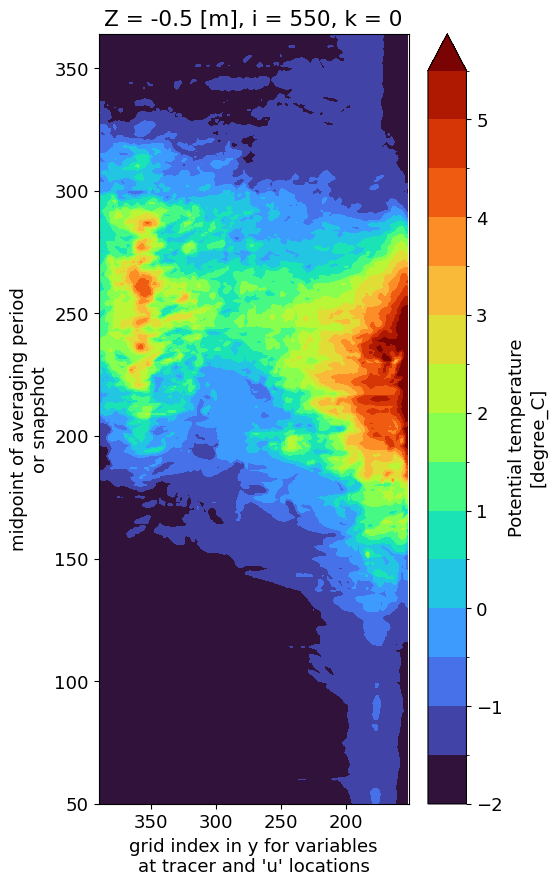

In [177]:
# Define contour levels
levels = np.arange(-2, 6, 0.5)  # Ensure it fully covers the data range

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 8))

# Plot Hovmöller Diagram using xarray's contourf function
sst_doy_mean.plot.contourf(ax=ax, x='j', y='dayofyear', levels=levels, cmap='turbo')
ax.set_xlim(390, 152)
ax.set_ylim(50, 364);

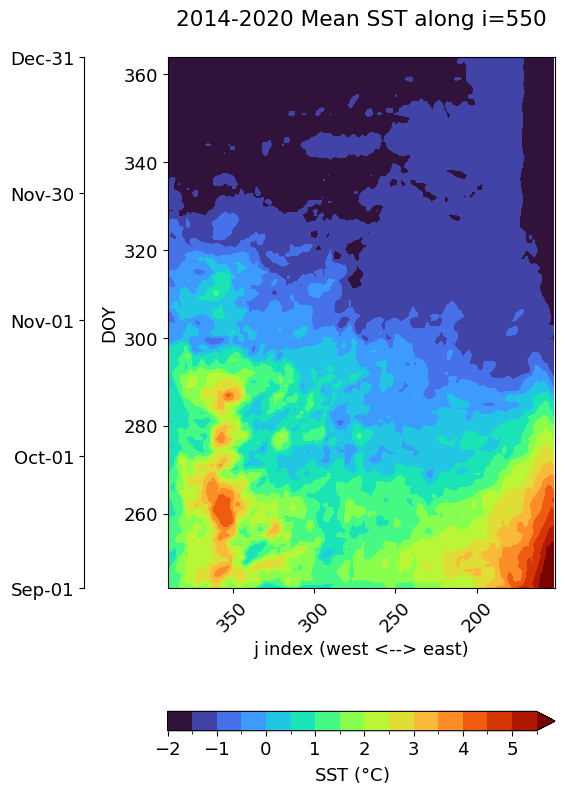

In [183]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 10))

# Plot Hovmöller Diagram
levels=np.arange(-2, 6, 0.5)
cbar_plot = sst_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap='turbo', levels=levels, add_colorbar=False)

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('2014-2020 Mean SST along i=550\n')
ax.set_xlabel('j index (west <--> east)')
ax.set_ylabel('DOY')
ax.set_xlim(390, 152)
ax.set_ylim(243, 364)
ax.tick_params(axis='x', rotation=45)

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.16)
cbar.set_label("SST ($\degree$C)")

plt.show()

### SSS

In [184]:
sss_select = salt_da.isel(i=550,j=slice(150,390),k=0)

In [185]:
# convert time to Day of Year (DOY)
doy = sss_select['time'].dt.dayofyear

# group by DOY and compute the mean across years
sss_doy_mean = sss_select.groupby(doy).mean(dim='time')

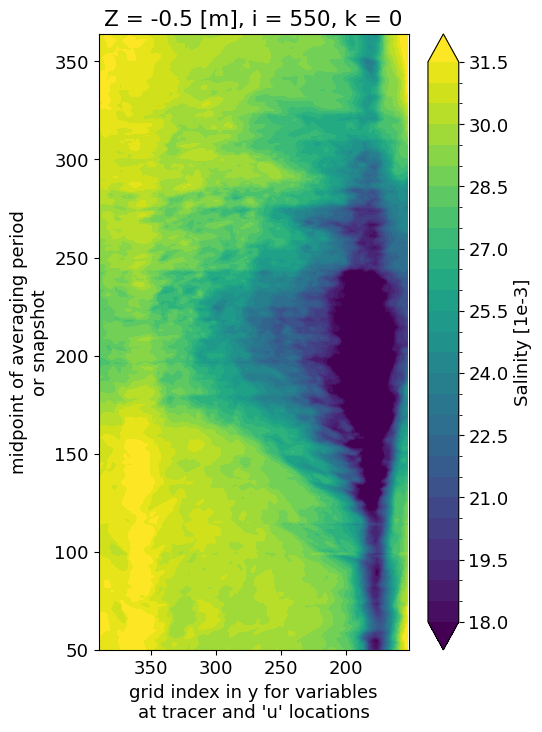

In [188]:
# Define contour levels
levels = np.arange(18, 32, 0.5)  # Ensure it fully covers the data range

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 8))

# Plot Hovmöller Diagram using xarray's contourf function
sss_doy_mean.plot.contourf(ax=ax, x='j', y='dayofyear', levels=levels, cmap='viridis')
ax.set_xlim(390, 152)
ax.set_ylim(50, 364);

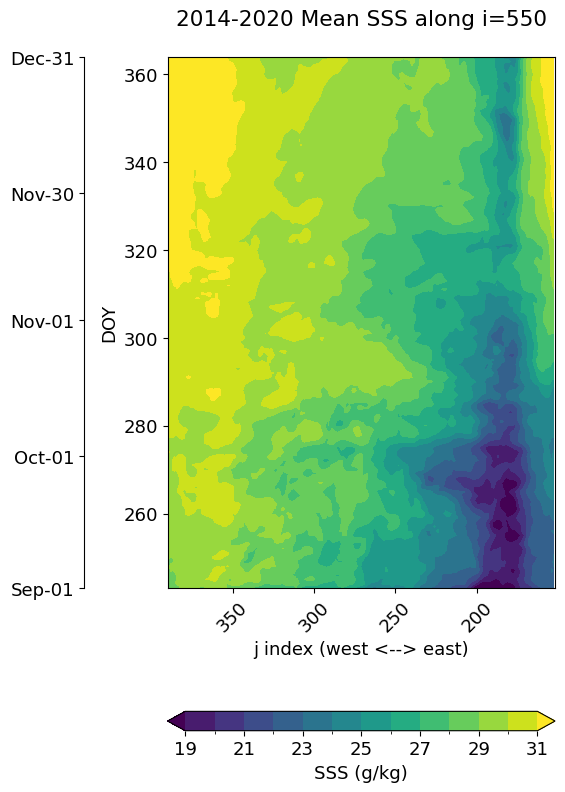

In [189]:
plt.rcParams['font.size'] = 13

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 10))

# Plot Hovmöller Diagram
levels = np.arange(19, 32, 1)
cbar_plot = sss_doy_mean.plot.contourf(
    ax=ax, x='j', y='dayofyear', cmap='viridis', levels=levels, add_colorbar=False)

# Create a secondary y-axis on the left for Month-Day labels
secax = ax.secondary_yaxis('left')

# Define tick locations and labels based on the day-of-year range
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")

# Move the secondary y-axis outward to reduce overlap
secax.spines['left'].set_position(('outward', 60))  # Adjust padding as needed

# Formatting the primary axis
ax.set_title('2014-2020 Mean SSS along i=550\n')
ax.set_xlabel('j index (west <--> east)')
ax.set_ylabel('DOY')
ax.set_xlim(390, 152)
ax.set_ylim(243, 364)
ax.tick_params(axis='x', rotation=45)

# Add horizontal colorbar below the plot
cbar = fig.colorbar(cbar_plot, orientation='horizontal', ax=ax, pad=0.16)
cbar.set_label("SSS (g/kg)")

plt.show()